# Day 24: In-Class Assignment

___


### <p style="text-align: right;"> &#9989;&nbsp; **Put your name here** </p>
#### <p style="text-align: right;"> &#9989;&nbsp; Put your group member names here</p>

## Parametric and non-parametric brain flows

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/lymphatic_system_csf_neuroscience.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 55%" alt="Scheme outlining the CSF outflow routes to the mandibular lymph nodes. Green: lymphatic vessels with black arrows indicating direction of flow, red: facial arteries.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://neurosciencenews.com/lymphatic-system-cranial-cavity-7912/" target="_blank">Ma et al (2017)</a></p>

### Learning goals of today's assignment

* Compare and contrast: Games-Howell/Tamhane's T<sub>2</sub> test check the differences between all possible pairs, while Dunnett's only checks the differences between control and everyone else.
* Use Dunn's test as a non-parametric alternative to Games-Howell/Tamhane's T<sub>2</sub>.
* Understand the trade-off between parametric and non-parametric tests.

## Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the Notebook. The assignment is due at the end of class.

___

## Importing the modules that we will need

Before we start anything, it is good practice to have all our imports as the first Python cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import scikit_posthocs as posthocs

---

## 1. CSF, revisited

We keep working with the mouse CSF dataset. [Jin et al (2025)](https://doi.org/10.1038/s41586-025-09052-5) demonstrate that precisely stimulating the lymphatics under skin on the neck and face can significantly enhance the flow of cerebrospinal fluid (CSF)&mdash;the liquid that cushions the brain and helps remove toxic waste&mdash;through lymphatic vessels. This offers a new approach to clearing brain waste using safe, non-invasive mechanical stimulation, rather than relying on drugs or surgical interventions. (Summary from [MedicalXpress](https://medicalxpress.com/news/2025-06-invasive-mechanical-brain-clearance.html))

> Jin, H., Yoon, JH., Hong, S.P. et al. (2025) [Increased CSF drainage by non-invasive manipulation of cervical lymphatics](https://doi.org/10.1038/s41586-025-09052-5). *Nature* **643**, 755&ndash;767

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/jin_etal_2025_f2.png" style="display:block; margin-left: auto; margin-right: auto; width: 65%" alt="Increased CSF drainage by non-invasive mechanical stimulation of scLVs.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1038/s41586-025-09052-5" target="_blank">Jin et al (2025)</a></p>

The main goal of today's activity is to reproduce the results from Figure 2c.

### 1.1 Data loading and visualization

&#9989;&nbsp;  **Task 1**

- Load and name `data` the "**TMR-dextran in scLVs**" sheet from the `'41587_2025_9052_MOESM8_ESM.xlsx'` file (attached in Canvas).
- Display its shape and first few rows. You should have 19 rows and 5 columns in total.
- Do you need to melt it?

In [2]:
# Load with pandas


### 1.2 Sidenote: NumPy support for NaNs

&#9989;&nbsp;  **Task 2**

Let's not melt this time: all the values for each region are in a single column&mdash;as opposed to spread through various rows.

However, later you will realize that `scikit_posthocs` like its data melted. We'll cross that bridge when we get there.

- Make a list `groups` with the column names that contain TMR values

In [3]:
# Your list
#groups = 

&#9989;&nbsp;  **Task 3**

- Grab the column with control values. **Do not** use explicitly the string `'No infusion'` but rather the correct indexed item from your prior list.
- What are the quantiles `quantiles` of this Series?
- Is that the result you expected?
- What if you [use `np.nanquantile` instead](https://numpy.org/doc/stable/reference/generated/numpy.nanquantile.html)?

In [4]:
# Quantiles
quantiles = np.linspace(0.1, 0.9, 10)

&#9989;&nbsp;  **Task 4**

The bread-and-butter of every data analysis: Q-Q plots to check for normality. Let's plot all the four gropus at once: three scLVs and control.

- Below is a skeleton of the plot: notice how everything boils down to a few lines in a loop
- Label axes/titles where appropriate to keep track of what Q-Q is of what.
- Do all the plots look like expected? What if you [use `np.nanquantile` instead](https://numpy.org/doc/stable/reference/generated/numpy.nanquantile.html)?

&#9989;&nbsp;  **Question 5**

- What is the difference between `np.quantile` and `np.nanquantile`?

As a sidenote, NumPy has functions [like `np.nanmean`](https://numpy.org/doc/stable/reference/generated/numpy.nanmean.html) [ and `np.nanstd`](https://numpy.org/doc/stable/reference/generated/numpy.nanstd.html). Pandas does ignore NaNs by default, which is why it is more convenient to work with Series. There is no `pd.quantile` funtion, though.

**Note**: Sometimes, you actually do *not* want NaN support since NaNs can work as canaries in the coalmine. If things break up because of NaNs, you know that you did something wrong before and you can go and fix it.

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### 1.3 Q-Q plots and jitterplots

The bread and butter of every initial data exploration.

In [5]:
fs = 12
times = [30, 60] # can also be done as data['Time (min)'].unique()

fig, ax = plt.subplots(len(times), len(groups), figsize=(2.5*len(groups), 2.5*len(times)))
for i in range(len(times)):
    df = data[data['Time (min)'] == times[i]]
    ax[i,0].set_ylabel(f'{times[i]} min', fontsize = fs)

    for j in range(len(groups)):

        y  = df[groups[j]]

        dataq = np.nanquantile(y, quantiles)
        normq = stats.norm.ppf(quantiles, loc=y.mean(), scale=y.std())

        ax[i,j].set_facecolor('snow')
        ax[i,j].set_title(groups[j], fontsize=fs)
        ax[i,j].tick_params(labelleft=False, labelbottom=False)
        ax[i,j].axline((y.iloc[0], y.iloc[0]), slope=1, c='r', zorder=1)
        ax[i,j].scatter(dataq, normq, c='b', zorder=2)

fig.tight_layout();

NameError: name 'groups' is not defined

And jitterplots, alongside the 95% confidence intervals (in black) and standard deviations (in red)
- The confidence intervals help us guess if it makes sense to expect the samples to be similar or not based on whether they overlap or not.
- The red bars help us guess if the data is homoscedastic, based on whether they look the same length or not: we add grid lines to avoid optical illusions.

NameError: name 'data' is not defined

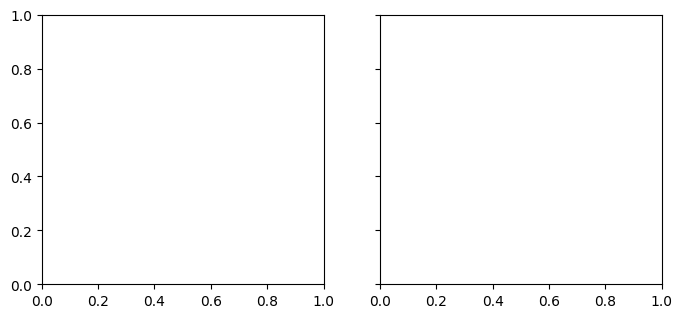

In [6]:
# Figure 2c, 2e
nudge = np.random.default_rng(42).uniform(-0.15, 0.15, 100)

fig, ax = plt.subplots(1,len(times),figsize=(4*len(times),3.5), sharey=True)
for i in range(len(times)):
    df = data[data['Time (min)'] == times[i]]
    ax[i].set_title(f'{times[i]} min', fontsize=fs)
    ax[i].set_facecolor('snow')
    ax[i].set_xticks(range(len(groups)), groups)
    ax[i].tick_params(labelsize=fs);
    ax[i].grid(axis='y', c='lightgray', zorder=1)

    for j in range(len(groups)):

        y  = df[groups[j]]/1000
        ci = stats.t.ppf(0.975, len(y)-1) * y.sem()
        sd = y.std()/2


        ax[i].scatter(j + nudge[:len(y)], y, marker = 'o', ec='darkgray', zorder=2)
        ax[i].errorbar(j , y.mean(), yerr=ci, color='k', mew=1.5, elinewidth=1.5, capsize=5, mfc='w', marker='D', zorder=3)
        ax[i].errorbar(j-.2 , y.mean(), yerr=sd, color='r', elinewidth=1.5, capsize=0, marker=None, zorder=3)

fig.supylabel('TMR-dextran in scLVs\n(a.u.$\\times10^3$)', fontsize=fs, ha='center')
fig.tight_layout();

&#9989;&nbsp;  **Question 6**

Ultimately, when we want to compare against control, we must make sure that the control looks as normal as possible.

- Based on the Q-Q plots, are the data normal-ish enough?
- Would you use Games-Howell, Dunnett, or Dunn's?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

---

## 2. Parametric vs Non-parametric tests

Remember that when discussing tests that require normality vs not requiring it, deep down we are talking:

- **Parametric:** the actual values are considered
- **Non-parametric:** the value *ranks* are considered

This value vs rank distinction is much more fundamental than normal vs non-normal decisions.

For the rest of the assignment, we will consider just the data taken 30 mins post TMR injection.

In [7]:
# This is the only data we will consider from here onward

df = data[data['Time (min)'] == times[0]]
df

NameError: name 'data' is not defined

- We will use tests from `scikit_posthocs`, which prefer when the data is in long format *aka* melted.
- This way, we can get rid of pesky NaNs while still having a dataframe

In [8]:
longdf = df.melt(['Time (min)'], var_name='group').dropna()
longdf.head()

NameError: name 'df' is not defined

### 2.1 Parametric distinctions

For 30 mins after, the data is not thaaat far away from the red identity line in the Q-Q plots. Let's wing it and go with parametric distinctions.

&#9989;&nbsp;  **Task 7**

- Perform a Tamhane's $T_2$ test (this is very similar to Games-Howell) [with `posthocs_tamhane`](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_tamhane.html).
- Use `longdf` as its main input. What is the name of column containing values? What is the name of the column indicating the group?

In [9]:
# Tamhane

&#9989;&nbsp;  **Question 8**

Just focus on how No Infusion compares against the other thre scLVs.
- Do the p-values match the jitterplots and confidence intervals?
- **More importantly**: Do they match the raw image from 2b?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

&#9989;&nbsp;  **Task 9**

But if we only care about control vs scLVs, we could try Dunnett's test.

- Ignore the homoscedasticity requirement for Dunnett and just compute it [with `posthoc_dunnett`](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunnett.html).
- Use `longdf` as the main input. What is the name of the control group?

In [10]:
# Dunnett

&#9989;&nbsp;  **Question 10**

Just focus on how No Infusion compares against the other thre scLVs.

- Do the p-values now match your *intuition* from the jitterplots?
- More importantly, do they match the raw image from 2b?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### 2.2 Non-parametric distinctions

Looking back at the red, standard deviation bars in the jitterplot, these are of different lengths. This is a strong visual indicator that the data is not homoscedastic. Which *can* break Dunnett&mdash;not that it necessarily will.

In any case, let's use a non-parametric test to avoid all sorts of normality and homoscedasticity shenanigans.

**Important**: You have to compute a Kruskal-Wallis H-test ([with `scipy.kruskal`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html)) as a prior step when doing non-parametric stuff.

In [11]:
# Get a list with 4 items, corresponding the TMR values for each of the 4 groups
samples = [longdf.loc[longdf['group'] == g, 'value'] for g in groups]
stats.kruskal(*samples)

# Alternatively, we can do
#stats.kruskal(*df[groups].T.to_numpy(), nan_policy='omit')

NameError: name 'groups' is not defined

The p-value is $< 0.05$ (our arbitrary criterion for significance), so there is indeed a non-parametric difference in TMR between groups.

&#9989;&nbsp;  **Task 11**

- Compute a Conover test it [with `posthoc_conover`](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_conover.html)&mdash;the non-parametric version of the likes of  Games-Howell and Tamhane's $T_2$.
- Use `longdf` as the main input.
- Make sure to adjust your p-values for false positives with the `p_adjust` parameter
    - Jin et al (2025) use the `bonferroni` correction, which is unnecesarily strict unless you want to only keep the *most* different pairs.
    - Benjamini-Hochberg&mdash;`fdr_bh`&mdash;is a better alternative in general (unless you have thousands of samples).

In [12]:
# Conover

&#9989;&nbsp;  **Question 12**

Just focus on how No Infusion compares against the other thre scLVs.

- Do the p-values now match your *intuition* from the jitterplots?
- More importantly, do they match the raw image from 2b?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

&#9989;&nbsp;  **Task 13**

Finally, let's do an actual non-parametric Dunnett.

- Compute again Conover's test **without** adjusting the p-values
- Make a Series with only the p-values compared against the control sample (three p-values in total)
- Adjust these p-values with Benjamini-Hochberg

In [13]:
# Conover + manual adjustments

&#9989;&nbsp;  **Question 14**

- Do the p-values now match your *intuition* from the jitterplots?
- More importantly, do they match the raw image from 2b?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

---

## 3. Parametric vs Non-parametric: Revisited

- How come Tamhane and Dunn gave us noticeably different results?
- For Dunn at first we did not even specify a Control group!

For ease of discussion, we copy/paste the jitterplot:

NameError: name 'groups' is not defined

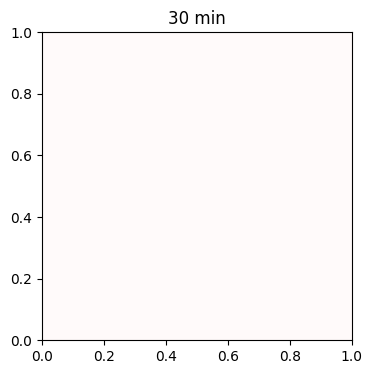

In [14]:
# Figure 2c, 2e
fig, ax = plt.subplots(1,1,figsize=(4,4), sharey=True);
ax = np.atleast_1d(ax); i = 0
ax[i].set_title(f'{times[i]} min', fontsize=fs)
ax[i].set_facecolor('snow')
ax[i].set_xticks(range(len(groups)), groups)
ax[i].tick_params(labelsize=fs);

for j in range(len(groups)):
    y  = df[groups[j]]/1000
    ci = stats.t.ppf(0.975, len(y)-1) * y.sem()
    ax[i].scatter(j + nudge[:len(y)], y, marker = 'o', zorder=2)
    ax[i].errorbar(j, y.mean(), yerr = ci, c='k', mfc='w', marker='D', capsize=10, zorder=3)
fig.supylabel('TMR-dextran in scLVs\n(a.u.$\\times10^3$)', fontsize=fs, ha='center')
fig.tight_layout();

Remember: post-hoc parametric tests look at value differences.

- There is no overlap between the intervals from scLVs CIs and the interval from control. Hence, it is not surprising that Tamhane says that these are different.
- The difference between scLV1 and scLV2 is 0 (intervals overlap)
- The difference between scLV2 and scLV3 is also 0
- Etc
- Even between scLV3 and control, the TMR difference is about $0.5$, and large compared to all possible differences.

But post-hoc non-parametric tests look at value *rank* differences.

- The lowest value *in the whole dataframe* is renumbered to `1`
- The second lowest is renumbered to `2`
- Etc.
- So the actual TMR values are discarded!

In that context, the scLV3 and control points are not that different.

### 3.1 But why did Dunnett work if it is parametric?

Dunnett only looks at the differences between samples and control. Looking again at the lower CI ends:

- scLV1 vs control is about $1.5$
- scLV2 vs control is about $0.8$
- scLV3 vs control is about $0.5$

This last difference is not that outstanding compared to the other two, and that's probably why Dunnett give it a large p-value.

### 3.2 Do not default to non-parametric tests

You might be tempted to always use non-parametric tests. No need to check for normality and no Q-Q plots!

When you convert your values to ranks, you can miss nuance. Imagine that the values of the upper half of scLV1 double. That will affect you parametric computations but your non-parametric setting is unaffected. That is some not-so subtle nuance lost!

Additionally, non-parametric tests tend to produce tiny p-values whenever you have large sample sizes. That is prime ground for false positives.

If your data is normal-ish, always do the parametric version of the tests: they are better at picking up finer differences. And if your sample size is large (like $n > 100$), parametric tests in general are better even if the Q-Q plots are not normal-looking. Remember that by the end of the day, the Central Limit Theorems tells us that all the means boil down to a normal. You just need a sample size large enough.

---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "In-class assignments" folder, find the appropriate submission link, and upload it there.

See you next class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri